In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import kagglehub
import os

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [8]:
path = kagglehub.dataset_download(
    "metricasecuador/handwritten-digits-version-1-hwd-v1"
)

print("Dataset root:", path)
print(os.listdir(path))

100%|██████████| 153M/153M [00:00<00:00, 267MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/metricasecuador/handwritten-digits-version-1-hwd-v1/versions/2
['HWD-V1']


In [9]:
# Automatically locate folder containing digit classes (0–9)
image_root = None

for root, dirs, files in os.walk(path):
    # Check if this directory contains class folders (0–9)
    if all(str(i) in dirs for i in range(10)):
        image_root = root
        break

print("Detected image root:", image_root)
print("Classes folders:", os.listdir(image_root))

Detected image root: /root/.cache/kagglehub/datasets/metricasecuador/handwritten-digits-version-1-hwd-v1/versions/2/HWD-V1/HWD-V1-Standard
Classes folders: ['9', '7', '8', '1', '2', '4', '3', '5', '6', '0']


In [10]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

In [11]:
dataset = datasets.ImageFolder(root=image_root, transform=transform)

print("Classes:", dataset.classes)
num_classes = len(dataset.classes)

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [12]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [13]:
class CNN_NoReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

In [14]:
class CNN_Reg(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

In [15]:
def setup_model(model):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    return model, criterion, optimizer, scheduler

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (preds == labels).sum().item()

        train_acc = 100 * correct_train / total_train

        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = 100 * correct / total

        scheduler.step()

        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    return history

In [17]:
model1, c1, o1, s1 = setup_model(CNN_NoReg())
history1 = train_model(model1, train_loader, val_loader, c1, o1, s1)

model2, c2, o2, s2 = setup_model(CNN_Reg())
history2 = train_model(model2, train_loader, val_loader, c2, o2, s2)

Epoch 1: Train Acc=97.56%, Val Acc=99.52%
Epoch 2: Train Acc=99.62%, Val Acc=99.59%
Epoch 3: Train Acc=99.76%, Val Acc=99.69%
Epoch 4: Train Acc=99.81%, Val Acc=99.72%
Epoch 5: Train Acc=99.85%, Val Acc=99.62%
Epoch 6: Train Acc=99.96%, Val Acc=99.77%
Epoch 7: Train Acc=99.96%, Val Acc=99.53%
Epoch 8: Train Acc=99.97%, Val Acc=99.73%
Epoch 9: Train Acc=99.98%, Val Acc=99.75%
Epoch 10: Train Acc=99.96%, Val Acc=99.78%
Epoch 1: Train Acc=96.18%, Val Acc=99.44%
Epoch 2: Train Acc=98.57%, Val Acc=99.68%
Epoch 3: Train Acc=98.79%, Val Acc=99.72%
Epoch 4: Train Acc=99.02%, Val Acc=99.48%
Epoch 5: Train Acc=99.18%, Val Acc=99.79%
Epoch 6: Train Acc=99.45%, Val Acc=99.80%
Epoch 7: Train Acc=99.48%, Val Acc=99.83%
Epoch 8: Train Acc=99.51%, Val Acc=99.80%
Epoch 9: Train Acc=99.54%, Val Acc=99.82%
Epoch 10: Train Acc=99.57%, Val Acc=99.80%


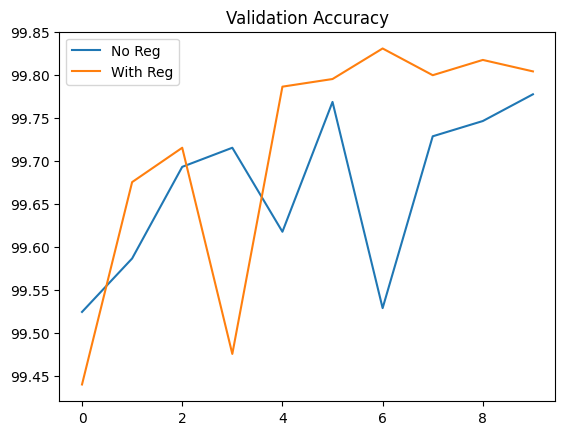

In [18]:
plt.plot(history1['val_acc'], label='No Reg')
plt.plot(history2['val_acc'], label='With Reg')
plt.legend()
plt.title("Validation Accuracy")
plt.show()

In [19]:
def evaluate(model):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.show()

    return y_true, y_pred

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2255
           1       1.00      1.00      1.00      2327
           2       1.00      1.00      1.00      2238
           3       1.00      1.00      1.00      2283
           4       1.00      1.00      1.00      2248
           5       1.00      1.00      1.00      2251
           6       1.00      1.00      1.00      2230
           7       1.00      1.00      1.00      2155
           8       1.00      1.00      1.00      2252
           9       1.00      1.00      1.00      2261

    accuracy                           1.00     22500
   macro avg       1.00      1.00      1.00     22500
weighted avg       1.00      1.00      1.00     22500



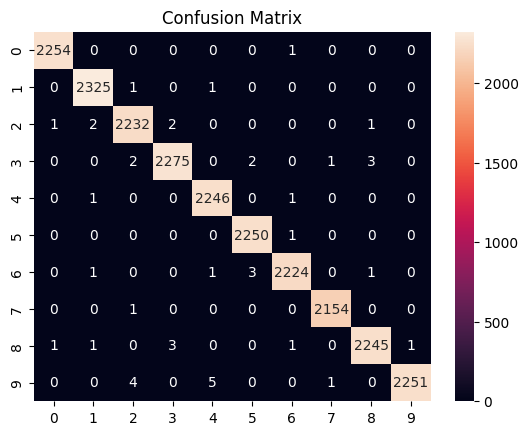

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2255
           1       1.00      1.00      1.00      2327
           2       1.00      1.00      1.00      2238
           3       1.00      1.00      1.00      2283
           4       1.00      1.00      1.00      2248
           5       1.00      1.00      1.00      2251
           6       1.00      1.00      1.00      2230
           7       1.00      1.00      1.00      2155
           8       1.00      1.00      1.00      2252
           9       1.00      1.00      1.00      2261

    accuracy                           1.00     22500
   macro avg       1.00      1.00      1.00     22500
weighted avg       1.00      1.00      1.00     22500



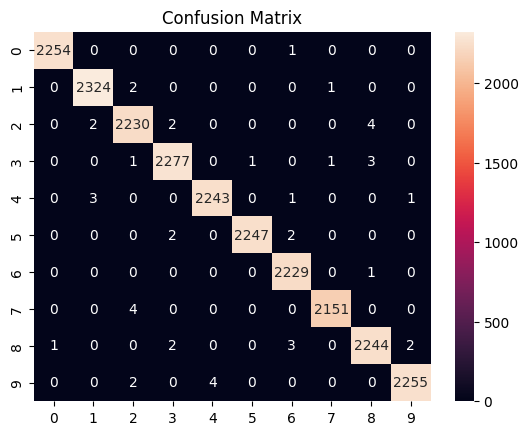

In [20]:
y1, p1 = evaluate(model1)
y2, p2 = evaluate(model2)

In [21]:
def analyze(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred)

    best = np.argmax(f1)
    worst = np.argmin(f1)

    print("Best class:", dataset.classes[best])
    print("Worst class:", dataset.classes[worst])

analyze(y2, p2)

Best class: 0
Worst class: 2


In [22]:
torch.save(model2.state_dict(), "CNN_model.pth")
print("Model saved successfully.")

Model saved successfully.
